## The House Price Prediction Model 

In [60]:
import numpy as np
import pandas as pd

### First loading and Exploring the data 

In [61]:
#Loading Dataset
data = pd.read_csv("AmesHousing.csv")
data.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [5]:
data.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [6]:
data.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

#### Exploring the Target (Price)
 ##### To see if the price is skewed or symmetric

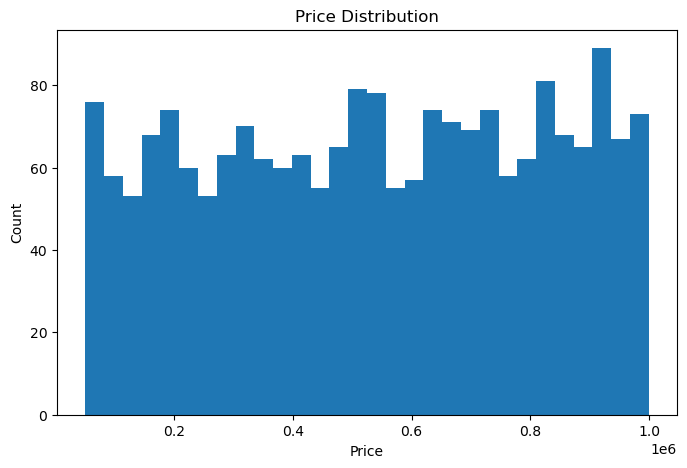

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(data["Price"], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price Distribution")
plt.show()

In [8]:
# The price is <0.5 so it is already in good condition
print(data["Price"].skew())

-0.06435063707629374


#### Now to find which element influences the price and how much?

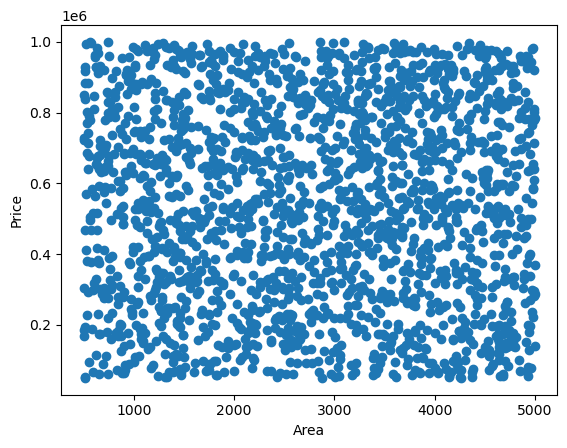

In [9]:
plt.scatter(data["Area"], data["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [10]:
data.groupby("Bedrooms")["Price"].mean()

Bedrooms
1    530561.622010
2    545546.521739
3    546977.894089
4    533696.930864
5    532500.124069
Name: Price, dtype: float64

In [11]:
data.groupby("Bathrooms")["Price"].mean()

Bathrooms
1    558757.752711
2    516589.876518
3    540201.713740
4    536478.481766
Name: Price, dtype: float64

In [12]:
data.groupby("Location")["Price"].mean()

Location
Downtown    536059.661290
Rural       538613.943038
Suburban    557416.333333
Urban       518963.548454
Name: Price, dtype: float64

## FEATURE ENGINEERING
#### Creating new features from the existing ones

In [13]:
# Feature 1: House Age
data["HouseAge"] = 2026 - data["YearBuilt"]

In [14]:
# Feature 2: Total Rooms
data["TotalRooms"] = (
    data["Bedrooms"] +
    data["Bathrooms"]
)

In [15]:
# Feature 3: Area Per Room
data["AreaPerRoom"] = (
    data["Area"] /
    data["TotalRooms"]
)

In [16]:
# Feature 4: IsLuxuryHouse
data["IsLuxuryHouse"] = (
    (data["Area"] > data["Area"].median()) &
    (data["Bathrooms"] >= 3)
).astype(int)

In [17]:
#Feature 5: Renovation Potential
data["OldLargeHouse"] = (
    (data["HouseAge"] > 40) &
    (data["Area"] > 2500)
).astype(int)

##  Data Preprocessing
#### Encoding
##### for understanding which features required Encoding Let's inspect categories first.

In [18]:
print(data["Location"].unique())
print(data["Condition"].unique())
print(data["Garage"].unique())

['Downtown' 'Suburban' 'Urban' 'Rural']
['Excellent' 'Good' 'Fair' 'Poor']
['No' 'Yes']


In [19]:
data = pd.get_dummies(
    data,
    columns=["Location","Condition","Garage"],
    drop_first=True
)

In [20]:
# so we will use onehot encoding techniques due to multiple categories
data.drop("Id", axis=1, inplace=True)
#ID contains no useful information.

In [21]:
print("Final columns after encoding:", data.columns.tolist())

Final columns after encoding: ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price', 'HouseAge', 'TotalRooms', 'AreaPerRoom', 'IsLuxuryHouse', 'OldLargeHouse', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Condition_Fair', 'Condition_Good', 'Condition_Poor', 'Garage_Yes']


#### SPLIT DATA 

In [22]:
from sklearn.model_selection import train_test_split

X = data.drop("Price", axis=1)
y = data["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (1600, 17) Test shape: (400, 17)


In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ["Location", "Condition", "Garage"]

numerical_features = [
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Floors",
    "YearBuilt",
    "HouseAge",
    "TotalRooms",
    "AreaPerRoom",
    "IsLuxuryHouse",
    "OldLargeHouse"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

## Model Training
### Base line Linear Regression model


In [24]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("R² Score:", r2_score(y_test, y_pred_lr))

R² Score: -0.008908785861624358


In [26]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))


RMSE: 280164.0976703982


In [27]:
print("MAE:", mean_absolute_error(y_test, y_pred_lr))

MAE: 244301.9605108191


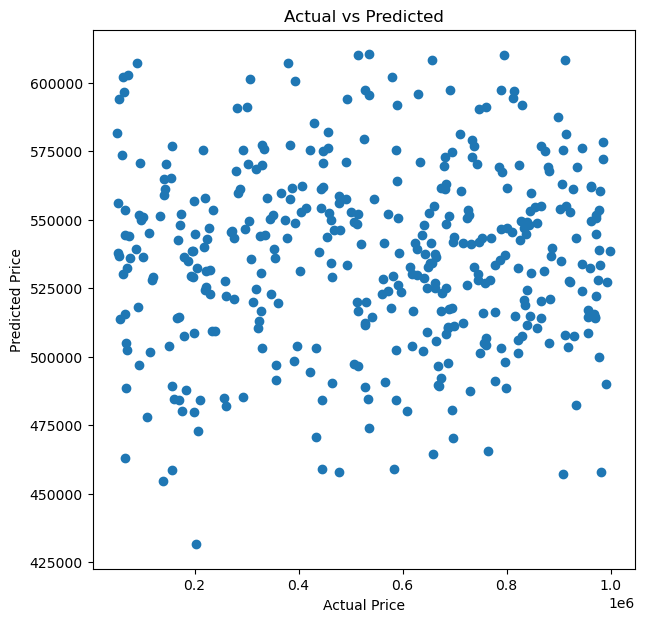

In [28]:
#For Linear Regression:
#If points lie near the diagonal, your model is doing well.
plt.figure(figsize=(7,7))

plt.scatter(y_test,y_pred_lr)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

### Random Forest 

In [29]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


In [30]:
print("R² Score:", r2_score(y_test, y_pred_rf))

R² Score: -0.12783484309564086


In [31]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


RMSE: 296216.52478679403


In [32]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

MAE: 254430.2838375


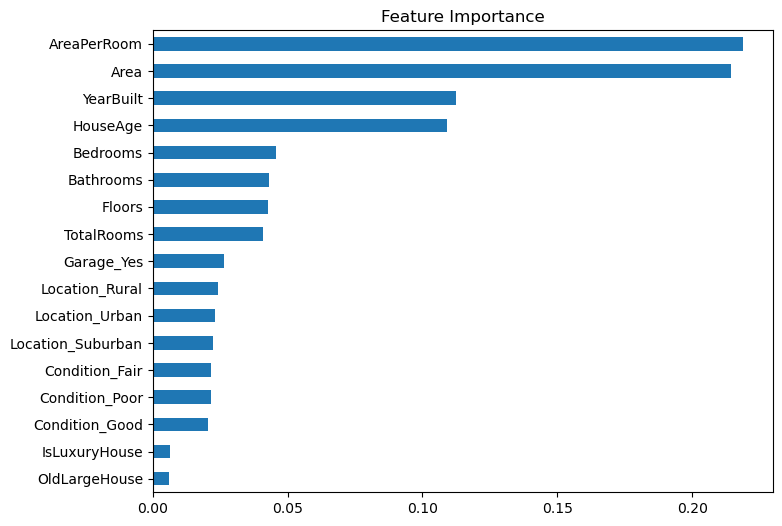

In [33]:
#Random Forest gives feature importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()

### CatBoost

In [34]:
#pip install catboost

In [35]:
from catboost import CatBoostRegressor
cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat.fit(X_train,y_train)

y_pred_cat = cat.predict(X_test)

In [36]:
print("R² Score:", r2_score(y_test, y_pred_cat))

R² Score: -0.11380629631504968


In [37]:
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_cat)))

RMSE: 294368.51912424125


In [38]:
print("MAE:", mean_absolute_error(y_test, y_pred_cat))

MAE: 251281.2286127522


In [39]:
# Comparison between 3 models
results = pd.DataFrame({
    "Model":["Linear Regression","Random Forest","CatBoostRegressor"],
    "R2":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_cat)
    ],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test,y_pred_lr)),
        np.sqrt(mean_squared_error(y_test,y_pred_rf)),
        np.sqrt(mean_squared_error(y_test,y_pred_cat))
    ],
    "MAE":[
        mean_absolute_error(y_test,y_pred_lr),
        mean_absolute_error(y_test,y_pred_rf),
        mean_absolute_error(y_test,y_pred_cat)

    ]
})

results

,Model,R2,RMSE,MAE
0,Linear Regression,-0.008909,280164.097670,244301.960511
1,Random Forest,-0.127835,296216.524787,254430.283837
2,CatBoostRegressor,-0.113806,294368.519124,251281.228613


In [40]:
# Create Parameter Grid
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [41]:
#Create Grid Search
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),

    param_grid=param_grid,

    scoring="r2",

    cv=5,

    n_jobs=-1,

    verbose=2
)

In [42]:
# Train
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='r2', verbose=2)

In [43]:
# Best Parameters
print(grid_search.best_params_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [44]:
# Best Score
print(grid_search.best_score_)

-0.028265023523997446


In [45]:
#Best Model
best_rf = grid_search.best_estimator_
print(best_rf)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=10,
                      random_state=42)


In [46]:
y_pred_best = best_rf.predict(X_test)
print(y_pred_best)

[624966.93102714 518507.8596529  522516.82366145 515652.59447679
 537220.14967232 575129.95495911 512677.7499748  590514.09472074
 575312.47385081 629064.66714223 545521.17520114 637763.73254726
 557556.9901912  551213.76625737 533013.56477119 511449.91408679
 598018.8190298  545331.56429584 573165.21419252 439713.31865107
 514927.67370391 482271.31961178 400696.33682342 664051.84826509
 507942.69106046 553189.71554694 487217.63892826 602056.34676663
 520181.27200349 540287.77862872 511010.55261405 569704.06288018
 584181.6773863  544964.0726383  424198.44778337 497508.24129051
 592776.26705808 543058.14899922 541495.09877129 463568.87842369
 533830.21789739 562954.15527761 572187.59734549 476772.33539861
 579984.0905483  571804.78989828 549028.24703368 511447.04189404
 509211.02163564 535620.02614285 486896.86632762 575287.33729658
 592218.61419602 587065.03709973 567453.61517013 559085.74320083
 548868.07783668 440450.19641135 458161.46510621 535159.39003208
 543350.50673178 527535.2

In [47]:
# Final Evaluation
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print("Optimized Random Forest")

print("R² :", r2_score(y_test, y_pred_best))

print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_best)))

print("MAE :", mean_absolute_error(y_test, y_pred_best))

Optimized Random Forest
R² : -0.059840564535678764
RMSE : 287148.6624359316
MAE : 248734.8793818586


In [48]:
comparison = pd.DataFrame({
    "Model": ["Random Forest (Default)", "Random Forest (Optimized)"],
    "R²": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_best)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_best))
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_best)
    ]
})

print(comparison)

                       Model        R²           RMSE            MAE
0    Random Forest (Default) -0.127835  296216.524787  254430.283837
1  Random Forest (Optimized) -0.059841  287148.662436  248734.879382


In [49]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
param_dist = {
    "iterations": [300, 500, 700],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9],
    "bagging_temperature": [0, 1, 3, 5]
}

random_search = RandomizedSearchCV(
    estimator=CatBoostRegressor(
        verbose=0,
        random_state=42
    ),

    param_distributions=param_dist,

    n_iter=20,

    cv=5,

    scoring="r2",

    random_state=42,

    n_jobs=-1
)

In [50]:
random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'bagging_temperature': [0, 1, 3, 5],
                                        'depth': [4, 6, 8, 10],
                                        'iterations': [300, 500, 700],
                                        'l2_leaf_reg': [1, 3, 5, 7, 9],
                                        'learning_rate': [0.01, 0.03, 0.05,
                                                          0.1]},
                   random_state=42, scoring='r2')

In [51]:
print(random_search.best_params_)

{'learning_rate': 0.01, 'l2_leaf_reg': 9, 'iterations': 500, 'depth': 6, 'bagging_temperature': 3}


In [52]:
best_cat = random_search.best_estimator_
print(best_cat)

CatBoostRegressor(bagging_temperature=3, depth=6, iterations=500, l2_leaf_reg=9, learning_rate=0.01, loss_function='RMSE', random_state=42, verbose=0)


In [53]:
y_pred_cat_best = best_cat.predict(X_test)

In [54]:
print("Optimized CatBoost")

print("R²:",
      r2_score(y_test, y_pred_cat_best))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test,
              y_pred_cat_best
          )
      ))

print("MAE:",
      mean_absolute_error(
          y_test,
          y_pred_cat_best
      ))

Optimized CatBoost
R²: -0.026817037731140303
RMSE: 282639.63387988607
MAE: 245982.19301477232


In [55]:
#after the parameter tunning
comparison = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest",
        "Random Forest Tuned",
        "CatBoost",
        "CatBoost Tuned"
    ],

    "R2":[
        r2_score(y_test,y_pred_lr),
        r2_score(y_test,y_pred_rf),
        r2_score(y_test,y_pred_best),
        r2_score(y_test,y_pred_cat),
        r2_score(y_test,y_pred_cat_best)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test,y_pred_lr)),
        np.sqrt(mean_squared_error(y_test,y_pred_rf)),
        np.sqrt(mean_squared_error(y_test,y_pred_best)),
        np.sqrt(mean_squared_error(y_test,y_pred_cat)),
        np.sqrt(mean_squared_error(y_test,y_pred_cat_best))
    ],

    "MAE":[
        mean_absolute_error(y_test,y_pred_lr),
        mean_absolute_error(y_test,y_pred_rf),
        mean_absolute_error(y_test,y_pred_best),
        mean_absolute_error(y_test,y_pred_cat),
        mean_absolute_error(y_test,y_pred_cat_best)
    ]
})

comparison.sort_values(
    by="R2",
    ascending=False
)

,Model,R2,RMSE,MAE
0,Linear Regression,-0.008909,280164.097670,244301.960511
4,CatBoost Tuned,-0.026817,282639.633880,245982.193015
2,Random Forest Tuned,-0.059841,287148.662436,248734.879382
3,CatBoost,-0.113806,294368.519124,251281.228613
1,Random Forest,-0.127835,296216.524787,254430.283837


In [56]:
corr = data.corr(numeric_only=True)

print(corr["Price"].sort_values(ascending=False))

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
OldLargeHouse        0.029215
IsLuxuryHouse        0.015862
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
HouseAge            -0.004845
AreaPerRoom         -0.011212
TotalRooms          -0.012478
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64


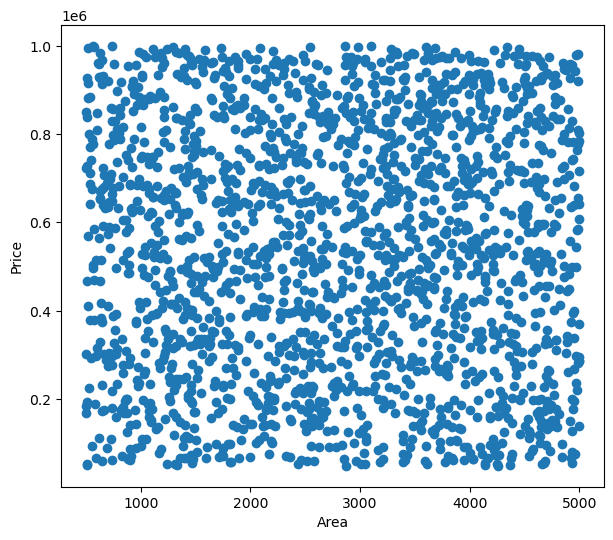

In [57]:
plt.figure(figsize=(7,6))
plt.scatter(data["Area"], data["Price"])
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

In [58]:
data.describe()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,HouseAge,TotalRooms,AreaPerRoom,IsLuxuryHouse,OldLargeHouse
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000,64.554000,5.556000,568.973139,0.269500,0.396500
std,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719,35.926695,1.794847,376.276941,0.443811,0.489293
min,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000,3.000000,2.000000,56.111111,0.000000,0.000000
25%,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000,33.000000,4.000000,303.000000,0.000000,0.000000
50%,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000,65.000000,6.000000,500.687500,0.000000,0.000000
75%,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000,96.000000,7.000000,725.437500,1.000000,1.000000
max,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000,126.000000,9.000000,2498.000000,1.000000,1.000000


In [59]:
corr = data.corr(numeric_only=True)
print(corr["Price"].sort_values(ascending=False))

Price                1.000000
Floors               0.055890
Condition_Fair       0.049218
Location_Suburban    0.040303
OldLargeHouse        0.029215
IsLuxuryHouse        0.015862
YearBuilt            0.004845
Garage_Yes           0.002842
Location_Rural       0.001890
Area                 0.001542
Bedrooms            -0.003471
HouseAge            -0.004845
AreaPerRoom         -0.011212
TotalRooms          -0.012478
Bathrooms           -0.015737
Condition_Good      -0.017179
Condition_Poor      -0.018437
Location_Urban      -0.038312
Name: Price, dtype: float64
